In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io

In [2]:
def leer_csv(ruta_archivo):
    """
    Función para leer un archivo CSV con cabecera. Los datos están separados por comas y están todos (valores y texto) entre comillas " "

    """
    try:
        df = pd.read_csv(
            ruta_archivo,
            sep=',',          # Indicamos que el separador es la coma
            header=0,         # Indicamos que la fila 0 (la primera) tiene las etiquetas
            quotechar='"'     # Le decimos que ignore las comas que estén dentro de las comillas
        )
        print("¡Archivo CSV cargado con éxito!")
        return df
        
    except FileNotFoundError:
        print(f"Error: No se ha encontrado el archivo en la ruta '{ruta_archivo}'.")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado al leer el CSV: {e}")
        return None



In [3]:
def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out

In [4]:
colores = {
   0: '#C72A66',    
   1: '#B16A3C',    
   2: '#1E8675',   
   3: "#7D1485"  
}

Primera gráfica: RMSE de los datos de validación

In [5]:
rmse_val=leer_csv('rmse_valheight.csv')
rmse_val_day=leer_csv('rmse_valheight_day.csv')
rmse_val_night=leer_csv('rmse_valheight_night.csv')

etiquetas = rmse_val.columns.tolist()
print("Las etiquetas del archivo rmse_valheight.csv son:")
for etiqueta in etiquetas:
    print(f" -> '{etiqueta}'")

etiquetas_day = rmse_val_day.columns.tolist()
print("Las etiquetas del archivo rmse_valheight_day.csv son:")
for etiqueta in etiquetas_day:
    print(f" -> '{etiqueta}'")

etiquetas_night = rmse_val_night.columns.tolist()
print("Las etiquetas del archivo rmse_valheight_night.csv son:")
for etiqueta in etiquetas_night:
    print(f" -> '{etiqueta}'")

epocas=rmse_val['Step']
epocas=round(epocas/(epocas.iloc[-1]/100))

epocas_day=rmse_val_day['Step']
epocas_day=round(epocas_day/(epocas_day.iloc[-1]/100))

epocas_night=rmse_val_night['Step']
epocas_night=round(epocas_night/(epocas_night.iloc[-1]/100))



¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_valheight.csv son:
 -> 'Step'
 -> 'test-model_231757 - Val RMSE Validación (metros)'
 -> 'test-model_231757 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_231757 - Val RMSE Validación (metros)__MAX'
Las etiquetas del archivo rmse_valheight_day.csv son:
 -> 'Step'
 -> 'test-model_051324 - Val RMSE Validación (metros)'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MAX'
Las etiquetas del archivo rmse_valheight_night.csv son:
 -> 'Step'
 -> 'test-model_062021 - Val RMSE Validación (metros)'
 -> 'test-model_062021 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_062021 - Val RMSE Validación (metros)__MAX'


<function matplotlib.pyplot.show(close=None, block=None)>

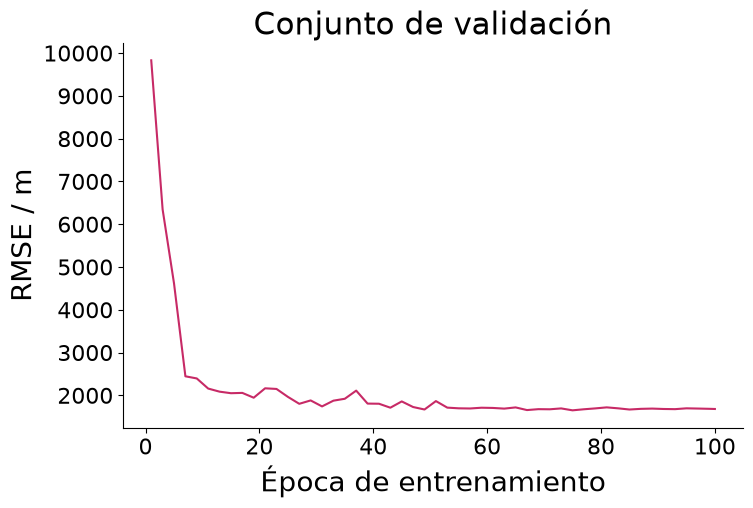

In [6]:
plt.figure(figsize=(8,5))

plt.plot(epocas, 10000*rmse_val['test-model_231757 - Val RMSE Validación (metros)'], linewidth=1.5, color=colores[0], label='Entrenamiento global')
# plt.plot(epocas_day, rmse_val_day['test-model_051324 - Val RMSE Validación (metros)'], linewidth=1.5, color=colores[2], label='Entrenamiento diurno')
# plt.plot(epocas_night, rmse_val_night['test-model_062021 - Val RMSE Validación (metros)'], linewidth=1.5, color=colores[1], label='Entrenamiento nocturno')

plt.xlabel('Época de entrenamiento', fontsize=20)
plt.ylabel('RMSE / m', fontsize=20)
plt.title('Conjunto de validación', fontsize=22)
# plt.legend(fontsize=20,  bbox_to_anchor=(1.0, 0.95))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show

In [7]:
rmse_train=leer_csv('rmse_trainheight.csv')
rmse_train_day=leer_csv('rmse_trainheight_day.csv')
rmse_train_night=leer_csv('rmse_trainheight_night.csv')

etiquetas2 = rmse_train.columns.tolist()
print("Las etiquetas del archivo rmse_trainheight.csv son:")
for etiqueta in etiquetas2:
    print(f" -> '{etiqueta}'")

etiquetas2_day = rmse_train_day.columns.tolist()
print("Las etiquetas del archivo rmse_trainheight_day.csv son:")
for etiqueta in etiquetas2_day:
    print(f" -> '{etiqueta}'")

etiquetas2_night = rmse_train_night.columns.tolist()
print("Las etiquetas del archivo rmse_trainheight_night.csv son:")
for etiqueta in etiquetas2_night:
    print(f" -> '{etiqueta}'")

epocas2=rmse_train['Step']
epocas2=epocas2/(epocas2.iloc[-1]/100)

epocas2_day=rmse_train_day['Step']
epocas2_day=epocas2_day/(epocas2_day.iloc[-1]/100)

epocas2_night=rmse_train_night['Step']
epocas2_night=epocas2_night/(epocas2_night.iloc[-1]/100)



¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_trainheight.csv son:
 -> 'Step'
 -> 'test-model_231757 - Train RMSE (meters)'
 -> 'test-model_231757 - Train RMSE (meters)__MIN'
 -> 'test-model_231757 - Train RMSE (meters)__MAX'
Las etiquetas del archivo rmse_trainheight_day.csv son:
 -> 'Step'
 -> 'test-model_051324 - Train RMSE (meters)'
 -> 'test-model_051324 - Train RMSE (meters)__MIN'
 -> 'test-model_051324 - Train RMSE (meters)__MAX'
Las etiquetas del archivo rmse_trainheight_night.csv son:
 -> 'Step'
 -> 'test-model_062021 - Train RMSE (meters)'
 -> 'test-model_062021 - Train RMSE (meters)__MIN'
 -> 'test-model_062021 - Train RMSE (meters)__MAX'


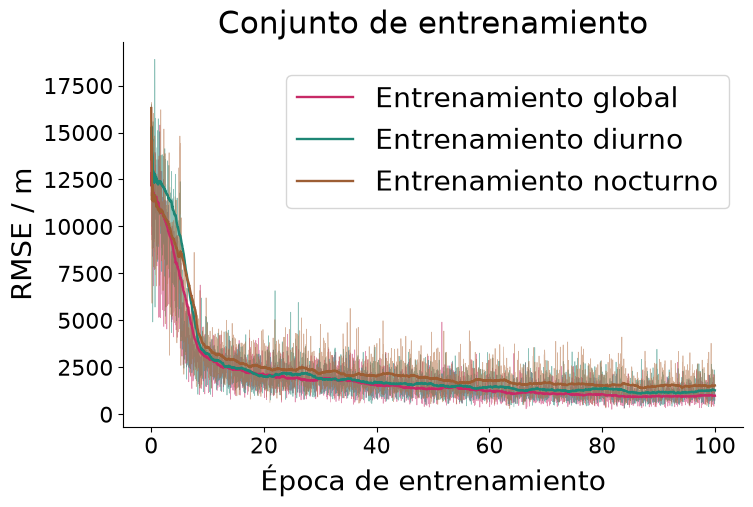

In [8]:
plt.figure(figsize=(8,5))

everyN=3
window=100

# 1. Extraemos los datos crudos de todos los modelos
val = 10000*rmse_val['test-model_231757 - Val RMSE Validación (metros)'][::everyN]
train = 10000*rmse_train['test-model_231757 - Train RMSE (meters)'][::everyN]

val_day = rmse_val_day['test-model_051324 - Val RMSE Validación (metros)'][::everyN]
train_day = rmse_train_day['test-model_051324 - Train RMSE (meters)'][::everyN]

val_night = rmse_val_night['test-model_062021 - Val RMSE Validación (metros)'][::everyN]
train_night =rmse_train_night['test-model_062021 - Train RMSE (meters)'][::everyN]

train_avg = train.rolling(window=window, min_periods=1).mean()
train_day_avg=train_day.rolling(window=window, min_periods=1).mean()
train_night_avg=train_night.rolling(window=window, min_periods=1).mean()



plt.plot(epocas2[::everyN], train, color=colores[0], linewidth=0.5, alpha=0.5)
plt.plot(epocas2_day[::everyN], train_day, color=colores[2], linewidth=0.5, alpha=0.5)
plt.plot(epocas2_night[::everyN], train_night, color=colores[1], linewidth=0.5, alpha=0.5)

plt.plot(epocas2[::everyN], train_avg, label='Entrenamiento global', color=colores[0], linewidth=1.7)
plt.plot(epocas2_day[::everyN], train_day_avg, label='Entrenamiento diurno', color=colores[2], linewidth=1.7)
plt.plot(epocas2_night[::everyN], train_night_avg, label='Entrenamiento nocturno', color="#9D5E34", linewidth=1.7)

plt.xlabel('Época de entrenamiento', fontsize=20)
plt.ylabel('RMSE / m', fontsize=20)
plt.title('Conjunto de entrenamiento', fontsize=22)
plt.legend(fontsize=20, bbox_to_anchor=(1.0, 0.95))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Parity plot

323
11830.0


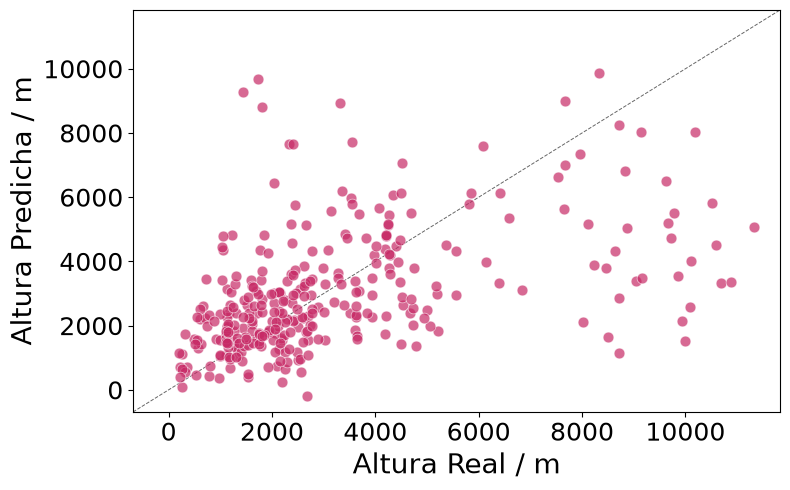

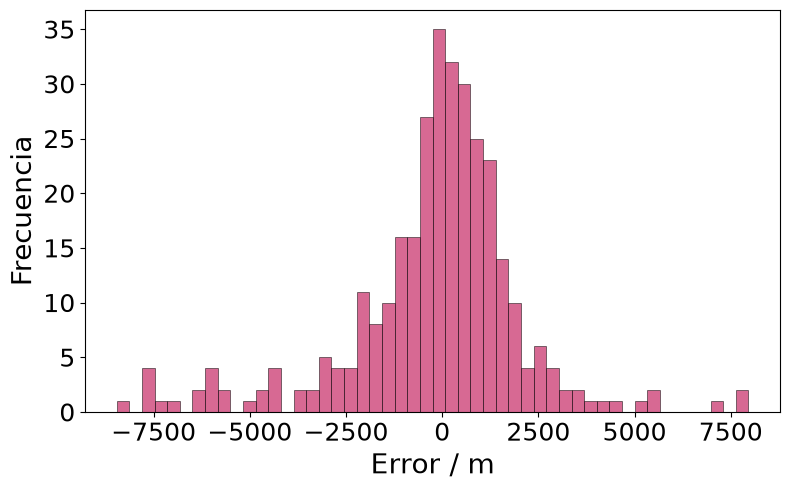

In [9]:
df = pd.read_csv('predicciones_detalladas_todoeldia.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real

# --- FIGURA 1: PARITY PLOT ---
fig1, ax1 = plt.subplots(figsize=(8,5))

ax1.scatter(real, predicho, alpha=0.7, color=colores[0], edgecolors='white', linewidth=0.5, s=60)

min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

print(max_val)

ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)

ax1.set_xlabel('Altura Real / m', fontsize=20)
ax1.set_ylabel('Altura Predicha / m', fontsize=20)
#ax1.set_title('Correlación de Alturas - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig1.tight_layout()

# --- FIGURA 2: HISTOGRAMA DEL ERROR ---
fig2, ax2 = plt.subplots(figsize=(8,5))

ax2.hist(error_con_signo, bins=50, color=colores[0], alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Error / m', fontsize=20)
ax2.set_ylabel('Frecuencia', fontsize=20)
#ax2.set_title('Distribución del Error - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig2.tight_layout()

plt.show()

323


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_31036\4148348307.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


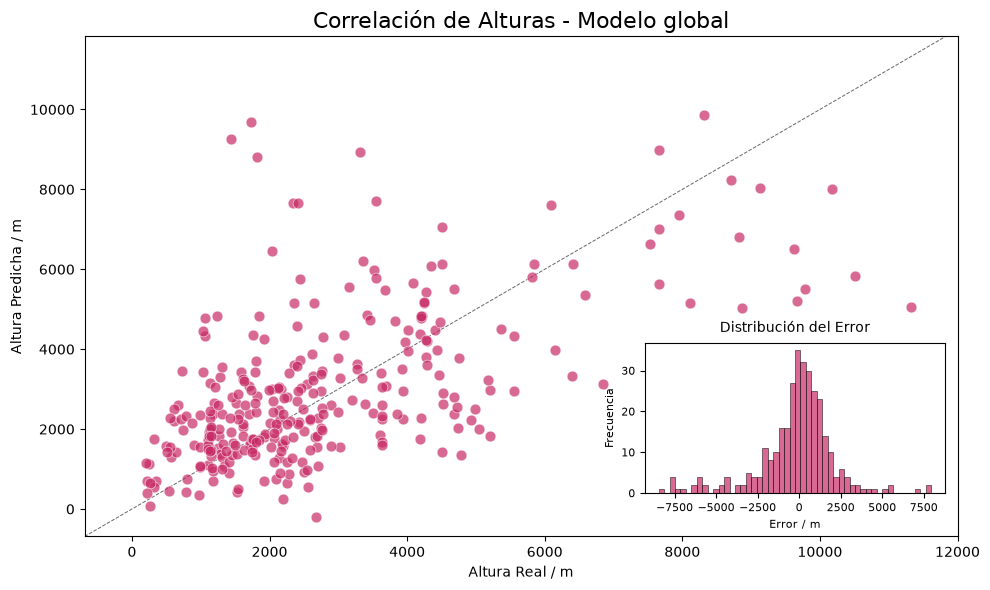

In [14]:
df = pd.read_csv('predicciones_detalladas_todoeldia.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

# Limpiamos posibles espacios en blanco
df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real #el error del archivo .txt es el absoluto (sin signo)


fig, ax = plt.subplots(figsize=(10,6))

# PARITY PLOT
ax.scatter(real, predicho, alpha=0.7, color=colores[0], edgecolors='white', linewidth=0.5, s=60)

# Límites para dibujar la línea ideal y=x
min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

# Dibujamos la línea de predicción perfecta
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

# Ajustamos los límites de los ejes para que el gráfico sea cuadrado
ax.set_xlim(min_val, 12000)
ax.set_ylim(min_val, max_val)

# Etiquetas y diseño del gráfico principal
ax.set_xlabel('Altura Real / m')
ax.set_ylabel('Altura Predicha / m')
ax.set_title('Correlación de Alturas - Modelo global', fontsize=16)

# --- HISTOGRAMA ERROR---
# La función add_axes toma [izquierda, abajo, ancho, alto] en coordenadas relativas (de 0 a 1)
# Lo colocamos abajo a la derecha, donde suele haber espacio vacío en los Parity Plots
ax_hist = fig.add_axes([0.65,0.17, 0.30, 0.25])

ax_hist.hist(error_con_signo, bins=50, color=colores[0], alpha=0.7, edgecolor='black', linewidth=0.5)


# Etiquetas del histograma
ax_hist.set_xlabel('Error / m', fontsize=8)
ax_hist.set_ylabel('Frecuencia', fontsize=8)
ax_hist.set_title('Distribución del Error', fontsize=10, backgroundcolor='white', pad=8)
ax_hist.tick_params(axis='both', which='major', labelsize=8)

# 3. Guardar y mostrar
plt.tight_layout()
# plt.savefig('parity_plot_convnext.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# ####### MODELO DIURNO

# df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\results\test-model_051324\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

# # Limpiamos posibles espacios en blanco
# df.columns = df.columns.str.strip()

# real = df['Real (m)']
# print(len(real))
# predicho = df['Predicho (m)']

# error_con_signo = predicho - real #el error del archivo .txt es el absoluto (sin signo)


# fig, ax = plt.subplots(figsize=(8,5))

# # PARITY PLOT
# ax.scatter(real, predicho, alpha=0.7, color=colores[2], edgecolors='white', linewidth=0.5, s=60)

# # Límites para dibujar la línea ideal y=x
# min_val = min(real.min(), predicho.min()) - 500
# max_val = max(real.max(), predicho.max()) + 500

# # Dibujamos la línea de predicción perfecta
# ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

# # Ajustamos los límites de los ejes para que el gráfico sea cuadrado
# ax.set_xlim(min_val, 12000)
# ax.set_ylim(min_val, max_val)

# # Etiquetas y diseño del gráfico principal
# ax.set_xlabel('Altura Real / m', fontsize=20)
# ax.set_ylabel('Altura Predicha / m', fontsize=20)
# plt.xticks(fontsize=18)
# plt.yticks(fontsize=18)
# ax.set_title('Modelo diurno', fontsize=22)

# #ax.grid(True, linestyle=':', alpha=0.6)

# # --- HISTOGRAMA ERROR---
# # La función add_axes toma [izquierda, abajo, ancho, alto] en coordenadas relativas (de 0 a 1)
# # Lo colocamos abajo a la derecha, donde suele haber espacio vacío en los Parity Plots
# ax_hist = fig.add_axes([0.65,0.17, 0.30, 0.25])

# ax_hist.hist(error_con_signo, bins=50, color=colores[2], alpha=0.7, edgecolor='black', linewidth=0.5)


# # Etiquetas del histograma
# ax_hist.set_xlabel('Error / m', fontsize=16)
# ax_hist.set_ylabel('Frecuencia', fontsize=16)
# ax_hist.set_title('Distribución del Error', fontsize=20, backgroundcolor='white', pad=8)
# ax_hist.tick_params(axis='both', which='major', labelsize=8)

# # 3. Guardar y mostrar
# plt.tight_layout()
# # plt.savefig('parity_plot_convnext.png', dpi=300, bbox_inches='tight')
# plt.show()

153
11830.0


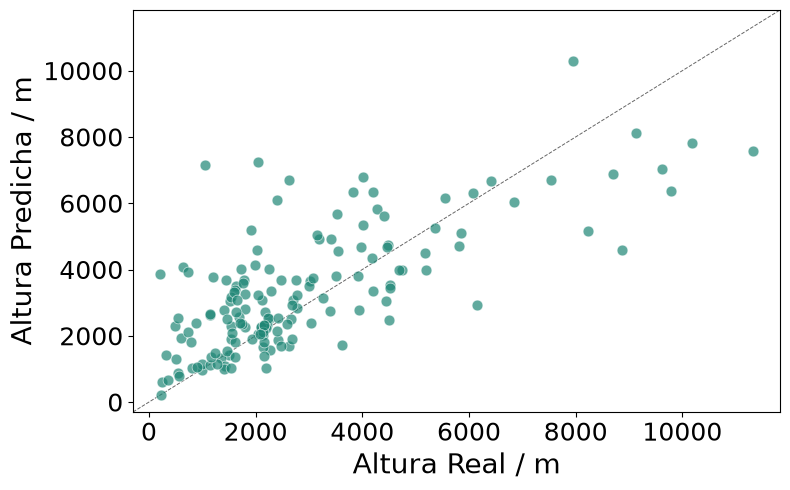

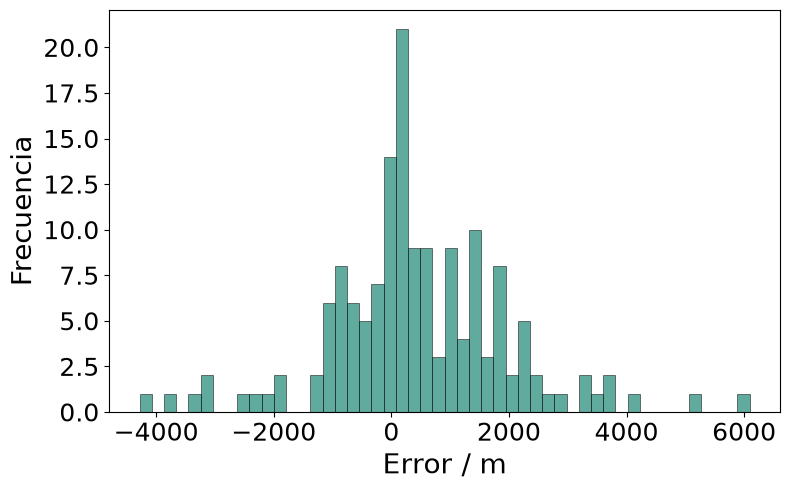

In [24]:
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\results\test-model_051324\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real

# --- FIGURA 1: PARITY PLOT ---
fig1, ax1 = plt.subplots(figsize=(8,5))

ax1.scatter(real, predicho, alpha=0.7, color=colores[2], edgecolors='white', linewidth=0.5, s=60)

min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

print(max_val)

ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)

ax1.set_xlabel('Altura Real / m', fontsize=20)
ax1.set_ylabel('Altura Predicha / m', fontsize=20)
#ax1.set_title('Correlación de Alturas - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig1.tight_layout()

# --- FIGURA 2: HISTOGRAMA DEL ERROR ---
fig2, ax2 = plt.subplots(figsize=(8,5))

ax2.hist(error_con_signo, bins=50, color=colores[2], alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Error / m', fontsize=20)
ax2.set_ylabel('Frecuencia', fontsize=20)
#ax2.set_title('Distribución del Error - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig2.tight_layout()

plt.show()

170
13189.57


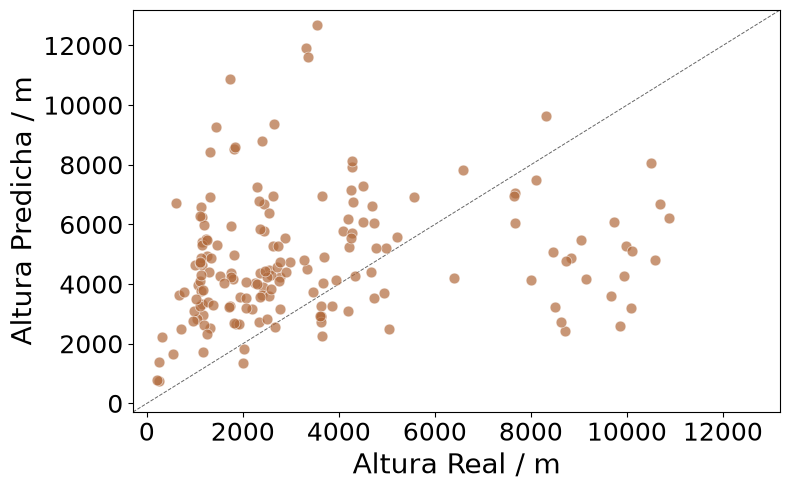

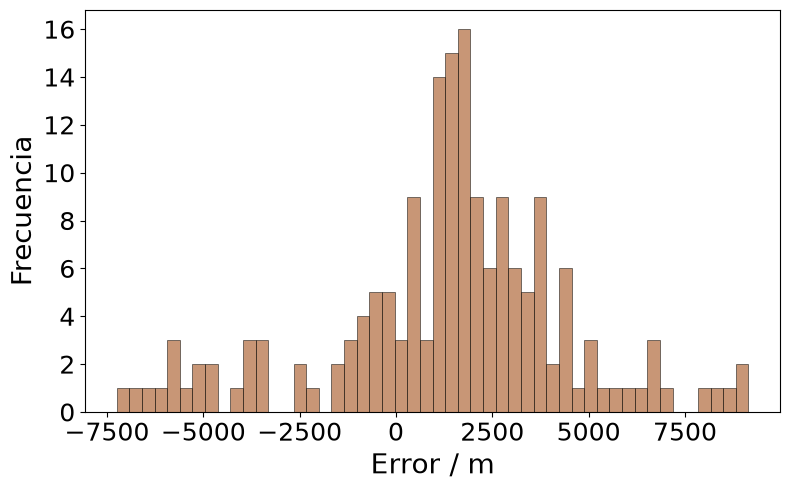

In [26]:
# NOCTURNO
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\results\test-model_062021\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real

# --- FIGURA 1: PARITY PLOT ---
fig1, ax1 = plt.subplots(figsize=(8,5))

ax1.scatter(real, predicho, alpha=0.7, color=colores[1], edgecolors='white', linewidth=0.5, s=60)

min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

print(max_val)

ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)

ax1.set_xlabel('Altura Real / m', fontsize=20)
ax1.set_ylabel('Altura Predicha / m', fontsize=20)
#ax1.set_title('Correlación de Alturas - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig1.tight_layout()

# --- FIGURA 2: HISTOGRAMA DEL ERROR ---
fig2, ax2 = plt.subplots(figsize=(8,5))

ax2.hist(error_con_signo, bins=50, color=colores[1], alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Error / m', fontsize=20)
ax2.set_ylabel('Frecuencia', fontsize=20)
#ax2.set_title('Distribución del Error - Modelo global', fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
fig2.tight_layout()

plt.show()

170


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_31036\3215576609.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


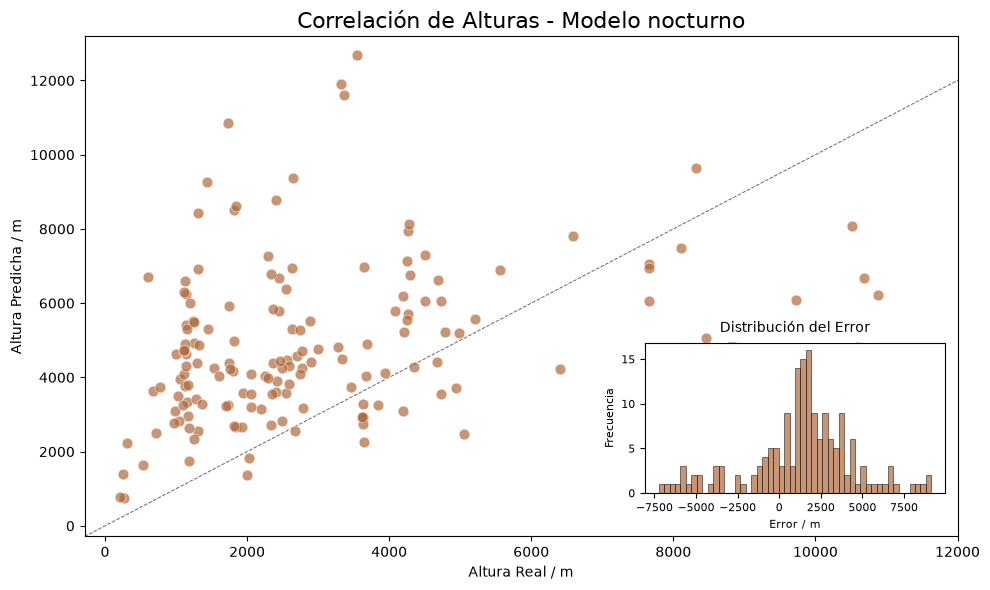

In [12]:
####### MODELO NOCTURNO

df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\results\test-model_062021\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

# Limpiamos posibles espacios en blanco
df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real #el error del archivo .txt es el absoluto (sin signo)


fig, ax = plt.subplots(figsize=(10,6))

# PARITY PLOT
ax.scatter(real, predicho, alpha=0.7, color=colores[1], edgecolors='white', linewidth=0.5, s=60)

# Límites para dibujar la línea ideal y=x
min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

# Dibujamos la línea de predicción perfecta
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, linewidth=0.7)

# Ajustamos los límites de los ejes para que el gráfico sea cuadrado
ax.set_xlim(min_val, 12000)
ax.set_ylim(min_val, max_val)

# Etiquetas y diseño del gráfico principal
ax.set_xlabel('Altura Real / m')
ax.set_ylabel('Altura Predicha / m')
ax.set_title('Correlación de Alturas - Modelo nocturno', fontsize=16)
#ax.grid(True, linestyle=':', alpha=0.6)

# --- HISTOGRAMA ERROR---
# La función add_axes toma [izquierda, abajo, ancho, alto] en coordenadas relativas (de 0 a 1)
# Lo colocamos abajo a la derecha, donde suele haber espacio vacío en los Parity Plots
ax_hist = fig.add_axes([0.65,0.17, 0.30, 0.25])

ax_hist.hist(error_con_signo, bins=50, color=colores[1], alpha=0.7, edgecolor='black', linewidth=0.5)


# Etiquetas del histograma
ax_hist.set_xlabel('Error / m', fontsize=8)
ax_hist.set_ylabel('Frecuencia', fontsize=8)
ax_hist.set_title('Distribución del Error', fontsize=10, backgroundcolor='white', pad=8)
ax_hist.tick_params(axis='both', which='major', labelsize=8)

# 3. Guardar y mostrar
plt.tight_layout()
# plt.savefig('parity_plot_convnext.png', dpi=300, bbox_inches='tight')
plt.show()